In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


In [2]:
def histograma(img, titulo="Histograma"):
    """Plota o histograma (256 bins) de uma imagem em tons de cinza."""
    plt.figure(figsize=(5, 4))
    plt.hist(img.ravel(), bins=256, range=(0, 255), color="gray")
    plt.title(titulo)
    plt.xlabel("Intensidade")
    plt.ylabel("Nº de pixels")
    plt.tight_layout()
    plt.show()


def estatisticas(img):
    """Estatísticas simples para ajudar no diagnóstico do histograma."""
    media = img.mean()
    desvio = img.std()
    pct_escuros = (img < 50).mean() * 100
    pct_claros = (img > 200).mean() * 100
    print(f"Média de intensidade: {media:.1f}")
    print(f"Desvio-padrão:        {desvio:.1f}")
    print(f"% de pixels < 50  (região escura): {pct_escuros:.1f}%")
    print(f"% de pixels > 200 (região clara):  {pct_claros:.1f}%")
    return media, desvio, pct_escuros, pct_claros


def expandir_contraste(img, L=None, H=None):
    """Expansão linear de contraste, mapeando [L, H] -> [0, 255]."""
    if L is None:
        L = int(img.min())
    if H is None:
        H = int(img.max())
    img_f = img.astype(np.float32)
    saida = (img_f - L) * (255.0 / (H - L))
    return np.clip(saida, 0, 255).astype(np.uint8)


def equalizar(img):
    """Equalização de histograma (cv2.equalizeHist)."""
    return cv2.equalizeHist(img)


def corrigir_gamma(img, gamma):
    """Correção gama: saida = 255 * (entrada/255) ** (1/gamma)."""
    inv_gamma = 1.0 / gamma
    tabela = np.array(
        [((i / 255.0) ** inv_gamma) * 255 for i in range(256)]
    ).astype(np.uint8)
    return cv2.LUT(img, tabela)


def plot_antes_depois(antes, depois, titulo_antes, titulo_depois, nome_arquivo):
    """Figura 2x2: imagem antes/depois na linha de cima, histogramas embaixo."""
    fig, ax = plt.subplots(2, 2, figsize=(10, 8))

    ax[0, 0].imshow(antes, cmap="gray", vmin=0, vmax=255)
    ax[0, 0].set_title(titulo_antes)
    ax[0, 0].axis("off")

    ax[0, 1].imshow(depois, cmap="gray", vmin=0, vmax=255)
    ax[0, 1].set_title(titulo_depois)
    ax[0, 1].axis("off")

    ax[1, 0].hist(antes.ravel(), bins=256, range=(0, 255), color="gray")
    ax[1, 0].set_title(f"Histograma — {titulo_antes}")
    ax[1, 0].set_xlabel("Intensidade")
    ax[1, 0].set_ylabel("Nº de pixels")

    ax[1, 1].hist(depois.ravel(), bins=256, range=(0, 255), color="gray")
    ax[1, 1].set_title(f"Histograma — {titulo_depois}")
    ax[1, 1].set_xlabel("Intensidade")
    ax[1, 1].set_ylabel("Nº de pixels")

    plt.tight_layout()
    plt.savefig(nome_arquivo, dpi=200, bbox_inches="tight")
    plt.show()



## Imagem 1 — Escura demais


Saving chewie-escuro.jpeg to chewie-escuro.jpeg


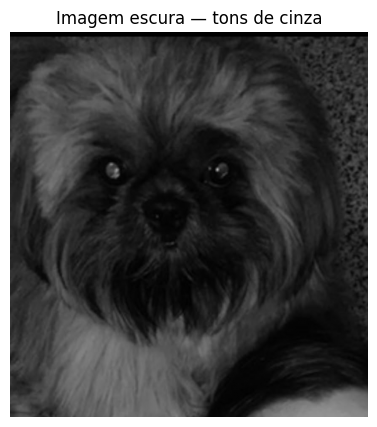

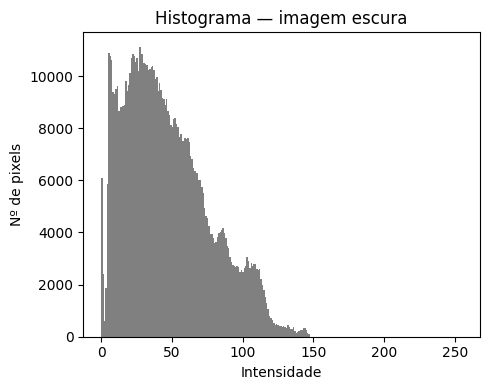

Média de intensidade: 46.6
Desvio-padrão:        30.2
% de pixels < 50  (região escura): 59.2%
% de pixels > 200 (região clara):  0.0%


(np.float64(46.64933645710103),
 np.float64(30.197564450927892),
 np.float64(59.20197013863652),
 np.float64(0.0))

In [3]:
arquivo_escura = files.upload()
nome_escura = next(iter(arquivo_escura))
img_escura_bgr = cv2.imread(nome_escura)
img_escura_gray = cv2.cvtColor(img_escura_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5, 5))
plt.imshow(img_escura_gray, cmap="gray", vmin=0, vmax=255)
plt.title("Imagem escura — tons de cinza")
plt.axis("off")
plt.show()

histograma(img_escura_gray, "Histograma — imagem escura")
estatisticas(img_escura_gray)


**Diagnóstico:**
As intensidades estão concentradas na faixa **baixa** com o pico mais alto entre 0 e 50.Isso indica uma imagem **subexposta**, com pouco ou nenhum uso da faixa clara do histograma

**Operação escolhida: correção de gama (γ > 1)**

Para clarear uma imagem subexposta sem "estourar" as áreas já claras, a correção de gama com γ > 1 é a mais indicada: ela expande proporcionalmente mais as intensidades baixas do que as altas (diferente da expansão linear de contraste, que trata toda a faixa de forma uniforme). Parâmetro usado: γ = 2,5.

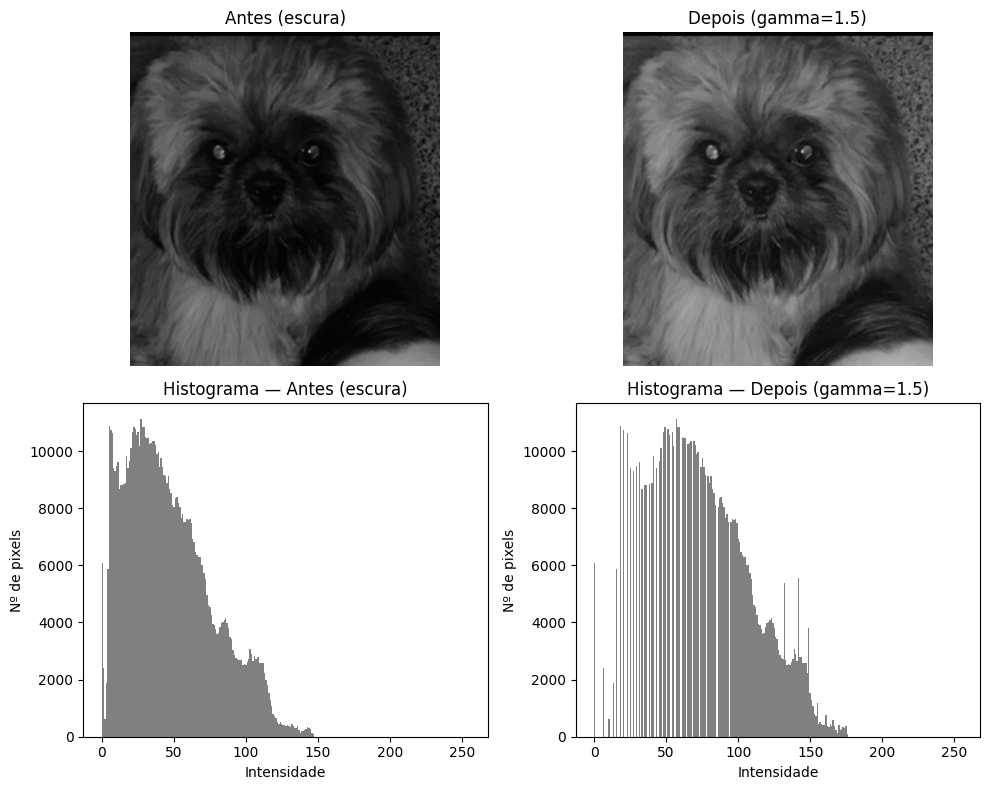

In [13]:
gamma_escura = 1.5
img_escura_corrigida = corrigir_gamma(img_escura_gray, gamma_escura)

plot_antes_depois(
    img_escura_gray, img_escura_corrigida,
    "Antes (escura)", f"Depois (gamma={gamma_escura})",
    "comparacao_escura.png",
)



## Imagem 2 — Clara demais / saturada


Saving chewie-claro.jpg to chewie-claro.jpg


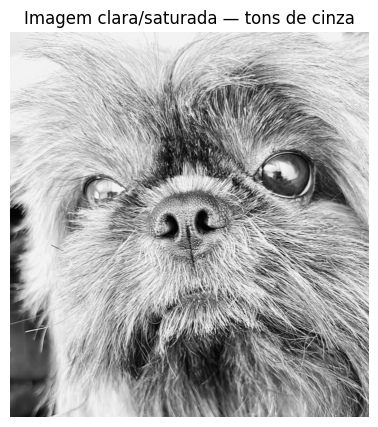

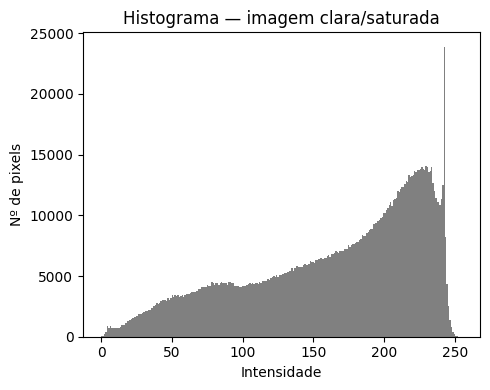

Média de intensidade: 164.3
Desvio-padrão:        62.0
% de pixels < 50  (região escura): 5.7%
% de pixels > 200 (região clara):  37.8%


(np.float64(164.27098298689413),
 np.float64(61.99845099699385),
 np.float64(5.685662870641706),
 np.float64(37.78478561771496))

In [14]:
arquivo_clara = files.upload()
nome_clara = next(iter(arquivo_clara))
img_clara_bgr = cv2.imread(nome_clara)
img_clara_gray = cv2.cvtColor(img_clara_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5, 5))
plt.imshow(img_clara_gray, cmap="gray", vmin=0, vmax=255)
plt.title("Imagem clara/saturada — tons de cinza")
plt.axis("off")
plt.show()

histograma(img_clara_gray, "Histograma — imagem clara/saturada")
estatisticas(img_clara_gray)


**Diagnóstico**
As intensidades estão fortemente deslocadas para a faixa alta, com um grande acúmulo entre 200 e 250, com um pico bem acentuado perto de 245–250.
Há muito pouco peso abaixo de 100. Isso confirma uma imagem superexposta/saturada: grande parte dos pixels está espremida perto do valor máximo, o que indica perda de detalhe nas áreas mais claras.

**Operação escolhida: correção de gama (γ > 0,4)**
Sobre o γ: com esse histograma tão deslocado pra direita, γ = 0,4 deve escurece bastante sem perder detalhes

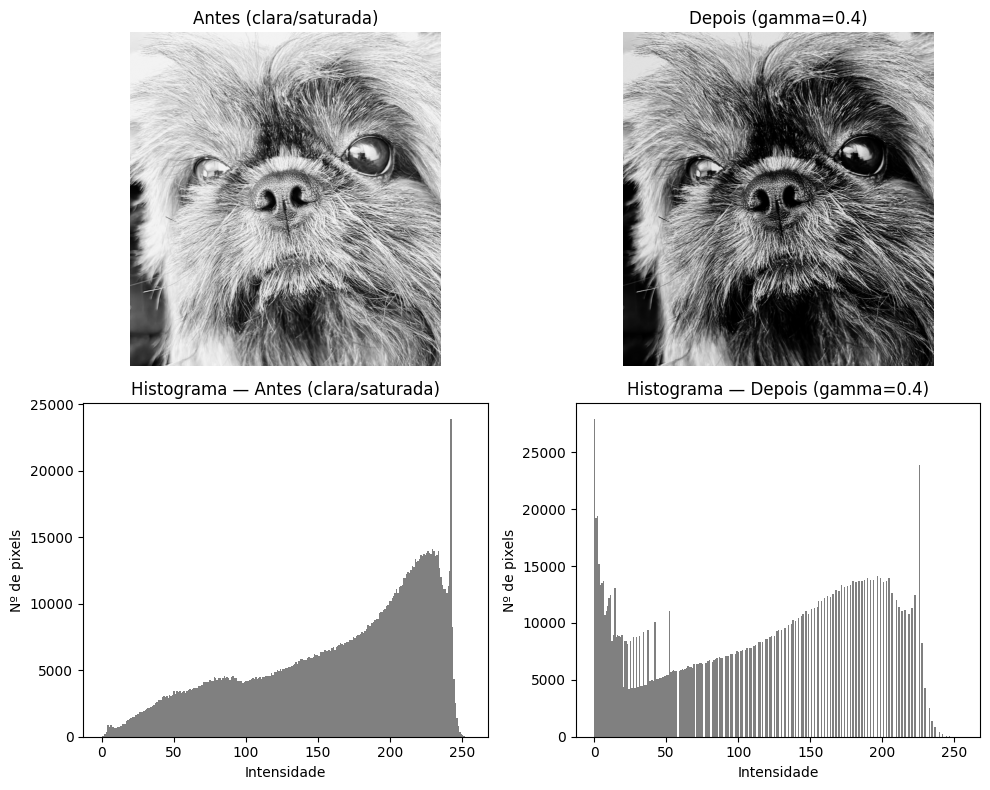

In [15]:
gamma_clara = 0.4
img_clara_corrigida = corrigir_gamma(img_clara_gray, gamma_clara)

plot_antes_depois(
    img_clara_gray, img_clara_corrigida,
    "Antes (clara/saturada)", f"Depois (gamma={gamma_clara})",
    "comparacao_clara.png",
)



## Imagem 3 — Bem exposta


Saving chewie-ideal.jpeg to chewie-ideal.jpeg


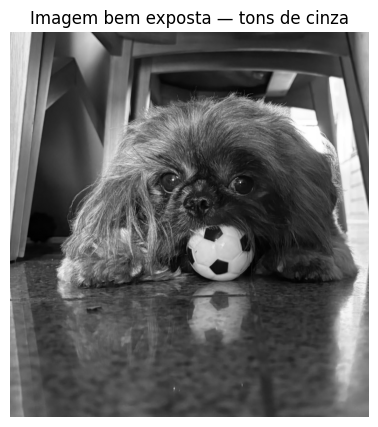

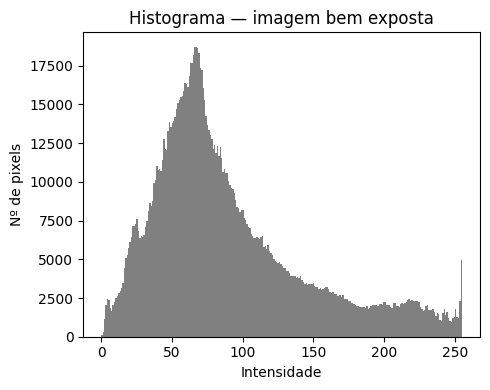

Média de intensidade: 90.7
Desvio-padrão:        55.6
% de pixels < 50  (região escura): 22.1%
% de pixels > 200 (região clara):  7.0%


(np.float64(90.7328485462417),
 np.float64(55.58501855897182),
 np.float64(22.09727364208027),
 np.float64(6.952969756413915))

In [16]:
arquivo_boa = files.upload()
nome_boa = next(iter(arquivo_boa))
img_boa_bgr = cv2.imread(nome_boa)
img_boa_gray = cv2.cvtColor(img_boa_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5, 5))
plt.imshow(img_boa_gray, cmap="gray", vmin=0, vmax=255)
plt.title("Imagem bem exposta — tons de cinza")
plt.axis("off")
plt.show()

histograma(img_boa_gray, "Histograma — imagem bem exposta")
estatisticas(img_boa_gray)


**Diagnóstico (edite com base no resultado acima):**
As intensidades já estão *em distribuídas ao longo de toda a faixa
0–255, sem concentração forte em nenhuma extremidade — o que é típico de uma
imagem com boa exposição e bom contraste.

**Operação escolhida: equalização de histograma**

Como a imagem já está visualmente bem exposta, a equalização serve aqui mais para demonstrar como a equalização pode melhorar uma foto que já está visualmente boa. Não há parâmetro livre (a equalização é
determinada automaticamente pelo histograma da imagem).

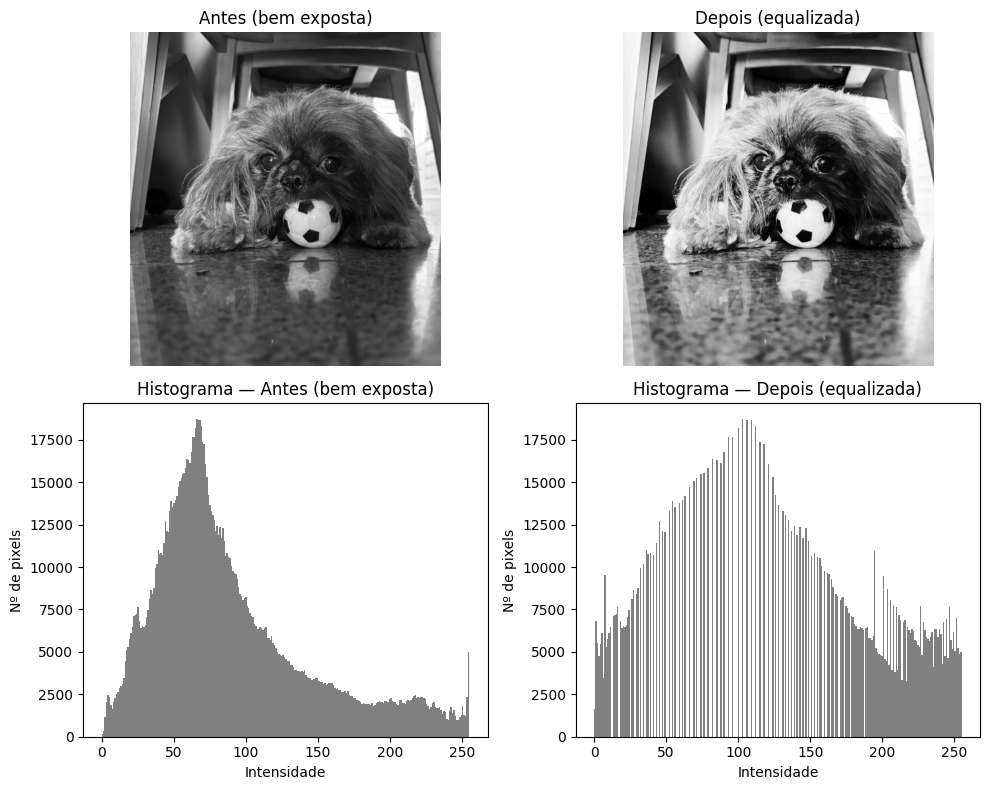

In [17]:
img_boa_equalizada = equalizar(img_boa_gray)

plot_antes_depois(
    img_boa_gray, img_boa_equalizada,
    "Antes (bem exposta)", "Depois (equalizada)",
    "comparacao_boa.png",
)


---
## Conclusão

**Em qual das três imagens a operação fez menos diferença? Por quê?**

De modo geral, a operação que fez menos diferença, foi a imagem bem exposta, a equalização encontra pouca margem para redistribuir as intensidades
fica próximo do original. Já nas imagens escura e clara/saturada, o
histograma original estava fortemente concentrado em uma faixa estreita de
intensidades, de modo que a correção de gama teve um efeito visualmente
muito mais perceptível, recuperando contraste e detalhes que antes estavam
"escondidos" nas sombras ou nas altas luzes.